In [ ]:
# =============================================================================
# MIT License
#
# Copyright (c) 2025 Jason Coleman
# UF MBI Microscopy Core / NeuroMicroscopy Co-op
# University of Florida
# jcoleman@ufl.edu
#
# Permission is hereby granted, free of charge, to any person obtaining a copy
# of this software and associated documentation files (the "Software"), to deal
# in the Software without restriction, including without limitation the rights
# to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
# copies of the Software, and to permit persons to whom the Software is
# furnished to do so, subject to the following conditions:
#
# The above copyright notice and this permission notice shall be included in all
# copies or substantial portions of the Software.
#
# THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
# IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
# FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
# AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
# LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
# OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE
# SOFTWARE.
# =============================================================================

# Notebook: get_tif_info_scanimage.ipy
# Version: 0.0.2
# Date: 2026-01-21

# Description:
#   Single-file processing of 2-channel ScanImage TIFF T (timelapse) stacks to extract general meta data and save to a CSV file.

# Changelog:
#   0.0.1 (2026-01-20) – Streamlined for 2-channels
#   0.0.2 (2026-01-22) – Added optional cell to process Z- or T-only TIF stacks
#                      - User only runs one or the other cell
  
# NOTE: This code is intended for research and educational use.
# Please cite or acknowledge the UF MBI Microscopy Core where appropriate.

# **License:** MIT  
# © 2025 Jason Coleman, UF MBI Microscopy Core / NeuroMicroscopy Co-op  
# University of Florida — jcoleman@ufl.edu


In [11]:
# Import ScanImage tif files (single-file)

# Works for ZT-, T-, Z- stacks

import numpy as np
import os
from pathlib import Path
import json
import socket
import tifffile # !pip install tifffile
import platform
import re
from datetime import datetime
import matplotlib.pyplot as plt

import pandas as pd

# Path to your ScanImage stack (replace 'text' with your directory
path = '/Users/jcoleman/Documents/--LARGE DATA--/#VonRoemeling/ZT20 TIFs'

# Name of the TIF file to import
# tif_filename1 = 'ZT20_25x_930_t0_area1_00001.tif' #'ZT20_25x_930_t5_area1_00001.tif'
tif_filename1 = 'ZT20_25x_930_t0_area1_00001.tif'
tif_filename2 = 'ZT20_25x_1100_t0_area1_00001.tif' #'ZT20_25x_1100_t5_area1_00001.tif'
# tif_filename2 = 'ZT20_25x_1100_t5_area1_00001.tif'

tif_file1 = os.path.join(
    path, 
    tif_filename1
)
tif_file2 = os.path.join(
    path, 
    tif_filename2
)

tif_data1 = tifffile.imread(tif_file1)
tif_data2 = tifffile.imread(tif_file2)

print(f'Pathname: {path}')
print(f'Filenames: {tif_filename1} | {tif_filename2}')
print(f'File1 shape: (e.g. Z, T, C, Y, X): {tif_data1.shape}')
print(f'File2 shape: (e.g. Z, T, C, Y, X): {tif_data2.shape}')

# NEXT STEPS - Run the next cell for 2-channel ZT data OR skip it and run the one after for T data


Pathname: /Users/jcoleman/Documents/--LARGE DATA--/#VonRoemeling/ZT20 TIFs
Filenames: ZT20_25x_930_t0_area1_00001.tif | ZT20_25x_1100_t0_area1_00001.tif
File1 shape: (e.g. Z, T, C, Y, X): (11, 20, 2, 512, 512)
File2 shape: (e.g. Z, T, C, Y, X): (11, 20, 2, 512, 512)


In [12]:
# Read in Channel1 (green) and Channel2 (red) from 2 TIF files, recombine for green-red
import tifffile as tiff
import numpy as np

def load_ztcyx(path):
    data = tiff.imread(path)
    if data.ndim != 5:
        raise ValueError(f"Expected 5D (Z,T,C,Y,X) but got {data.shape}")
    return data

def recombine_ch1_ch2(tif1_ch1, tif2_ch2, filename=None):
    if tif1_ch1.shape != tif2_ch2.shape:
        msg = (
            f"SKIP: shape mismatch "
            f"Ch1 {tif1_ch1.shape} vs Ch2 {tif2_ch2.shape}"
        )
        if filename:
            msg += f" | file={filename}"
        print(msg)
        return None  # sentinel → skip downstream

    return np.stack([tif1_ch1, tif2_ch2], axis=2)  # (Z,T,2,Y,X)

tif1 = load_ztcyx(tif_file1)  # (Z,T,C,Y,X)
tif2 = load_ztcyx(tif_file2)  # (Z,T,C,Y,X)

# Extract desired channels
tif1_ch1 = tif1[:, :, 0, :, :]   # (Z,T,Y,X)
tif2_ch2 = tif2[:, :, 1, :, :]   # (Z,T,Y,X)
# tif2_ch2 = tif2[0:11, :, 1, :, :]   # mismatch for ch1-ch2 Z-correlation tests (Z,T,Y,X)

# # Validate shape compatibility
# if tif1_ch1.shape != tif2_ch2.shape:
#     raise ValueError(f"Shape mismatch: {tif1_ch1.shape} vs {tif2_ch2.shape}")

# # Recombine into new "tif_data" with 2 channels
# tif_data = np.stack([tif1_ch1, tif2_ch2], axis=2)  # (Z,T,C,Y,X)
# tif_data = recombine_ch1_ch2(tif1_ch1, tif2_ch2, filename=tif_file1)

# if tif_data is None:
#     # Optionally log this somewhere
#     skipped_files.append(tif_file1)
#     skip_log.append({
#         "file_ch1": tif1_path,
#         "file_ch2": tif2_path,
#         "shape_ch1": tif1_ch1.shape,
#         "shape_ch2": tif2_ch2.shape,
#         "reason": "Z/T/Y/X mismatch"
#     })
#     return  # move to next file
skipped_files = []
skip_log = []
tif_data = recombine_ch1_ch2(tif1_ch1, tif2_ch2)

if tif_data is None:
    skipped_files.append(path)
    skip_log.append({
        "file_ch1": tif_file1,
        "file_ch2": tif_file2,
        "shape_ch1": tif1_ch1.shape,
        "shape_ch2": tif2_ch2.shape,
        "reason": "Z/T/Y/X mismatch"
    })

    print(skipped_files)
    print(skip_log)
else:
    print("FUTURE: run_qc(tif_data)")

    # Now your existing QC code works as-is
    Z, T, C, Y, X = tif_data.shape

    print(f'Ch1 from {tif_filename1} + Ch2 from {tif_filename2} combined into single tif_data')

FUTURE: run_qc(tif_data)
Ch1 from ZT20_25x_930_t0_area1_00001.tif + Ch2 from ZT20_25x_1100_t0_area1_00001.tif combined into single tif_data


In [13]:
# Average across T for every Z
    # (Eg for ZT20*.tif file, 20 T frames will be averaged into a single plane/2D image at each Z)
    # Calculate the average intensity for each Z-plane (17 total)
    # across all time frames (20 total) per plane.
    # Formula: Z_avg[i] = mean(Frames[i, 0:20])

    # Process: Z-Average Projection
    # Input:  (Z=17, T=20, Y, X)
    # Output: (Z=17, Y, X) 
    # Expression: Avg_Zi = Σ(T_0...T_19) / 20


tif_Zavg = tif_data.mean(axis=1)  # (Z, C, Y, X)
print(tif_Zavg.shape)

zslice_middle = int(len(tif_Zavg)/2)
zsliceNum = zslice_middle
print(f"Plot Z-slice#: {zsliceNum}")

(11, 2, 512, 512)
Plot Z-slice#: 5


In [14]:
# Z data averaged over T (e.g. result = (Z,C,Y,X))
# use for Z T-avg'ed data (ie Avg_Zi = Σ(T_0...T_19) / 20)

channel_1_data = tif_Zavg[:, 0, :, :]  # shape: (33, 512, 512)
channel_2_data = tif_Zavg[:, 1, :, :]  # shape: (33, 512, 512)

print(f"Channel 1   shape: {channel_1_data.shape}")
print(f"Channel 2   shape: {channel_2_data.shape}")

# Transpose to (Y, X, Z) if needed for your code
channel_1_data = np.transpose(channel_1_data, (1, 2, 0))  # shape: (512, 512, 33)
channel_2_data = np.transpose(channel_2_data, (1, 2, 0))  # shape: (512, 512, 33)

print(f"Channel 1 reshape: {channel_1_data.shape}")
print(f"Channel 2 reshape: {channel_2_data.shape}")

# zsliceNum = 10 # Optional value for plotting below, replaces the middle value from above
zsliceNum

Channel 1   shape: (11, 512, 512)
Channel 2   shape: (11, 512, 512)
Channel 1 reshape: (512, 512, 11)
Channel 2 reshape: (512, 512, 11)


5

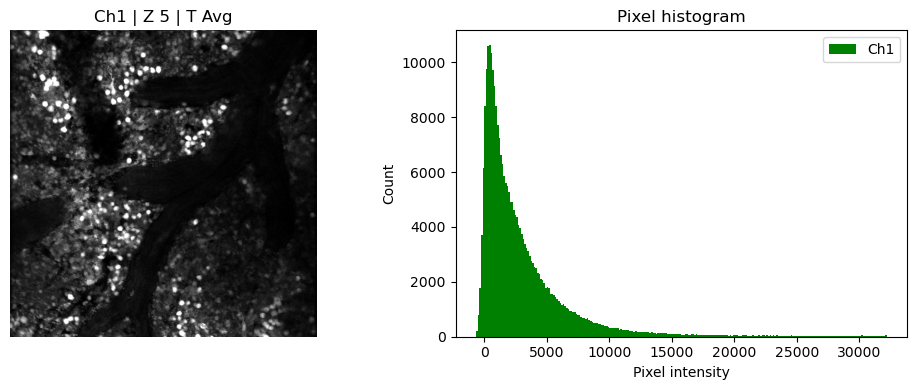

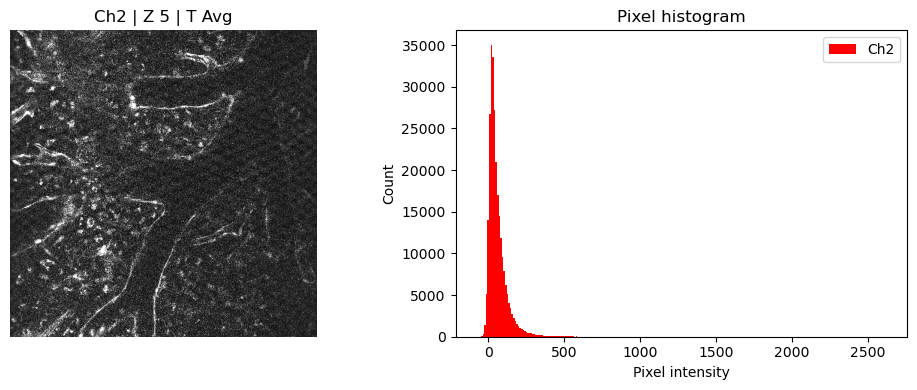

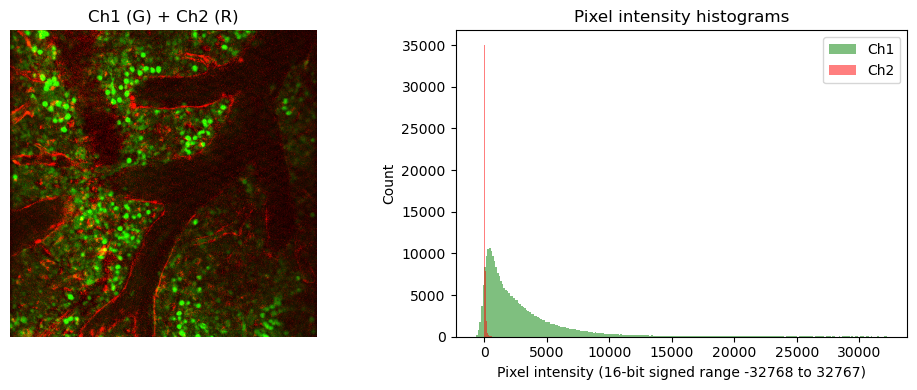

In [15]:
# Sanity check the channels - w/ histograms and ch1+ch2 overlay

# import numpy as np
# import matplotlib.pyplot as plt

def plot_slice_histogram(img, histcolor, zsliceNum=0, frame='Avg', channel='signal'):
    # img = channel_1_data[:, :, frame]
    pixels = img.ravel()
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    
    # Image
    vmin = np.percentile(img, 1)
    vmax = np.percentile(img, 99)

    axes[0].imshow(img, cmap='gray',
               vmin=vmin,
               vmax=vmax)
    #axes[0].imshow(img, cmap='gray')
    axes[0].set_title(f'{channel} | Z {zsliceNum} | T {frame}')
    axes[0].axis('off')
    
    # Histogram
    # axes[1].hist(pixels, bins=256, density=True, color=histcolor)
    axes[1].hist(pixels, bins=256, density=False, color=histcolor, label=channel)
    axes[1].set_xlabel('Pixel intensity')
    # axes[1].set_ylabel('Probability density')
    axes[1].set_ylabel('Count')
    axes[1].set_title('Pixel histogram')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

def plot_overlay_and_hist(img1, img2, zsliceNum=0, frame=None,
                          bins=256, alpha=0.5, Saturation=32767):
    """
    img1, img2: (Y, X) arrays for channel 1 and channel 2
    """

    # Build RGB overlay (normalize for display only)
    # def norm(im):
    #     im = im.astype(float)
    #     return (im - im.min()) / (im.max() - im.min() + 1e-9)
    def norm(im, pmin=1, pmax=99):
        im = im.astype(float)
        vmin = np.percentile(im, pmin)
        vmax = np.percentile(im, pmax)
        return np.clip((im - vmin) / (vmax - vmin + 1e-9), 0, 1)

    rgb = np.zeros((*img1.shape, 3))
    rgb[..., 1] = norm(img1)   # green
    rgb[..., 0] = norm(img2)   # red

    # Flatten pixels
    p1 = img1.ravel()
    p2 = img2.ravel()

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # ---- Overlay image ----
    axes[0].imshow(rgb)
    title = "Ch1 (G) + Ch2 (R)"
    if zsliceNum is not None and frame is not None:
        title += f" | Z {zsliceNum} | T {frame}"
    axes[0].set_title(title)
    axes[0].axis('off')

    # ---- Overlaid histograms ----
    axes[1].hist(p1, bins=bins, density=False,
                 color='green', alpha=alpha, label='Ch1')
    axes[1].hist(p2, bins=bins, density=False,
                 color='red', alpha=alpha, label='Ch2')

    axes[1].set_xlabel(f'Pixel intensity (16-bit signed range -32768 to 32767)')
    axes[1].set_ylabel('Count')
    axes[1].set_title('Pixel intensity histograms')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

def preprocess_background(img, bg_pctle=5, norm_pctle=99):
    # perform background subtraction and normalization
    # 1. Keep raw int16 data untouched
    img_raw = img
    
    # 2. Background subtract (robust)
    bg = np.percentile(img_raw, bg_pctle)
    img_bg = img_raw - bg
    
    # 3. (Optional) Normalize to reference
    img_norm = img_bg / np.percentile(img_bg, norm_pctle)

    return img_bg, img_norm

# run the functions here
# frame = 5 # select T frame
# img_chan1 = channel_1_data[:, :, frame]
# img_chan2 = channel_2_data[:, :, frame]

# Need to distinguish Z, T etc explicitlu hehre
img_chan1 = channel_1_data[:, :, zsliceNum]
img_chan2 = channel_2_data[:, :, zsliceNum]

img_chan1_background, img_chan1_normalized = preprocess_background(img_chan1, bg_pctle=5, norm_pctle=99)
img_chan2_background, img_chan2_normalized = preprocess_background(img_chan2, bg_pctle=5, norm_pctle=99)

plot_slice_histogram(img_chan1_background, 'green', zsliceNum, channel='Ch1')
plot_slice_histogram(img_chan2_background, 'red', zsliceNum, channel='Ch2')
plot_overlay_and_hist(img_chan1_background, img_chan2_background,
                      zsliceNum=zsliceNum, frame=None)

In [16]:
# # For debugging

# import tifffile as tiff
# import re

# def dump_scanimage_tags(tif_path, max_chars=6000):
#     with tiff.TiffFile(tif_path) as tf:
#         p0 = tf.pages[0]
#         plast = tf.pages[-1]

#         def show(page, label):
#             print(f"\n===== {label} =====")
#             for tagname in ["Artist", "Software", "ImageDescription"]:
#                 tag = page.tags.get(tagname)
#                 val = tag.value if tag else None
#                 if val is None:
#                     print(f"{tagname}: <None>")
#                     continue
#                 s = str(val)
#                 print(f"{tagname}: len={len(s)}  head:\n{s[:max_chars]}")
#                 # quick “do we have the big SI header?”
#                 hits = re.findall(r"(?m)^(SI\.[^\s=]+)\s*=", s)
#                 if hits:
#                     print(f"Found {len(hits)} SI.* keys, e.g.: {hits[:15]}")
#                 else:
#                     print("Found 0 SI.* keys in this tag.")

#         show(p0, "PAGE 0")
#         show(plast, "LAST PAGE")

# # dump_scanimage_tags("/Users/jcoleman/Documents/--LARGE DATA--/#Khodayari/260113_NK/process1/fileCELL_3x_750nm_00004.tif")
# dump_scanimage_tags(tif_file)


In [17]:
# Output image metadata to csv- and/or txt-friendly format

from pathlib import Path
import json
import socket
import platform
import re
import pandas as pd
import tifffile as tiff
from datetime import datetime

def _parse_epoch_line(desc_text: str):
    """
    Parse ScanImage epoch line like:
      epoch = [2026  1 13 16 24 29.809]
    Returns datetime or None.
    """
    if not desc_text:
        return None, None

    m = re.search(r"(?m)^epoch\s*=\s*\[([^\]]+)\]\s*$", desc_text)
    if not m:
        return None, None

    raw = m.group(1).strip()  # "2026  1 13 16 24 29.809"
    parts = [p for p in re.split(r"\s+", raw) if p]
    if len(parts) < 6:
        return None, raw

    y = int(float(parts[0]))
    mo = int(float(parts[1]))
    d = int(float(parts[2]))
    h = int(float(parts[3]))
    mi = int(float(parts[4]))
    sec = float(parts[5])

    sec_int = int(sec)
    usec = int(round((sec - sec_int) * 1e6))
    dt = datetime(y, mo, d, h, mi, sec_int, usec)
    return dt, raw

def _get_si_value(software_text: str, key: str):
    """
    Extract a ScanImage 'SI.key = value' line from the Software tag text.
    Returns the value string (stripped) or None.
    """
    if not software_text:
        return None
    m = re.search(rf"(?m)^{re.escape(key)}\s*=\s*(.*)$", software_text)
    return m.group(1).strip() if m else None

def _parse_si_vector(txt):
    if not txt:
        return None
    s = txt.strip().strip("[]")
    parts = [p for p in s.replace(",", " ").split() if p]
    try:
        return [float(p) for p in parts]
    except ValueError:
        return None

def fov_um_from_tiff_resolution(page):
    tags = page.tags

    # XResolution/YResolution are (num, denom) tuples
    res_x_num, res_x_den = tags["XResolution"].value
    res_y_num, res_y_den = tags["YResolution"].value
    res_x = res_x_num / res_x_den  # pixels per unit
    res_y = res_y_num / res_y_den

    unit = tags["ResolutionUnit"].value  # 2=inches, 3=cm

    height, width = page.shape  # rows, cols

    if unit == 3:  # cm
        width_um  = (width  / res_x) * 1e4
        height_um = (height / res_y) * 1e4
    elif unit == 2:  # inch
        width_um  = (width  / res_x) * 25400
        height_um = (height / res_y) * 25400
    else:
        return None, None, None, None  # unsupported / missing

    um_per_px_x = width_um / width
    um_per_px_y = height_um / height
    
    return width_um, height_um, um_per_px_x, um_per_px_y


def export_scanimage_metadata(tif_path, out_csv=None):
    tif_path = Path(tif_path)

    with tiff.TiffFile(tif_path) as tf:
        p0 = tf.pages[0]
        
        # FOV fallback from TIFF resolution tags (matches what Fiji reports)
        fov_x_um_tiff, fov_y_um_tiff, um_per_pixel_x_tiff, um_per_pixel_y_tiff = fov_um_from_tiff_resolution(p0)


        software = str(p0.tags.get("Software").value) if p0.tags.get("Software") else ""
        artist = str(p0.tags.get("Artist").value) if p0.tags.get("Artist") else ""
        desc = str(p0.tags.get("ImageDescription").value) if p0.tags.get("ImageDescription") else ""

        imaging_fov_um = _get_si_value(software, "SI.hRoiManager.imagingFovUm")

        # ---------- File info ----------
        stat = tif_path.stat()
        file_created = datetime.fromtimestamp(stat.st_ctime)
        file_modified = datetime.fromtimestamp(stat.st_mtime)

        # ---------- Acquisition epoch -> datetime ----------
        acq_dt, acq_epoch_raw = _parse_epoch_line(desc)

        # # ---------- ROI geometry (Artist tag JSON) ----------
        # fov_x_um = fov_y_um = px_x = px_y = None
        # scan_zoom_factor = None
        # try:
        #     roi_root = json.loads(artist)
        #     roi = roi_root["RoiGroups"]["imagingRoiGroup"]["rois"]
        #     scanfield = roi["scanfields"]
        #     # fov_x_um, fov_y_um = scanfield["sizeXY"]
        #     fov_xy = _parse_si_vector(imaging_fov_um)

        #     if fov_xy and len(fov_xy) == 2:
        #         fov_x_um, fov_y_um = fov_xy
        #         um_per_pixel_x = fov_x_um / px_x
        #         um_per_pixel_y = fov_y_um / px_y
        #     else:
        #         fov_x_um = fov_y_um = um_per_pixel_x = um_per_pixel_y = None

        #     px_x, px_y = scanfield["pixelResolutionXY"]
        #     scan_zoom_factor = roi.get("UserData", {}).get("scanZoomFactor", None)

        # except Exception:
        #     # If Artist isn't valid JSON, just leave these as None
        #     pass
        # ---------- ROI geometry (Artist tag JSON) ----------
        fov_x_um = fov_y_um = px_x = px_y = None
        um_per_pixel_x = um_per_pixel_y = None
        scan_zoom_factor = None
        
        try:
            roi_root = json.loads(artist)
            roi = roi_root["RoiGroups"]["imagingRoiGroup"]["rois"]
            scanfield = roi["scanfields"]
        
            # pixel dims (needed for um/px)
            px_x, px_y = scanfield["pixelResolutionXY"]
        
            # calibrated FOV from Software tag (preferred)
            fov_xy = _parse_si_vector(imaging_fov_um)
            if fov_xy and len(fov_xy) == 2 and px_x and px_y:
                fov_x_um, fov_y_um = fov_xy
                um_per_pixel_x = fov_x_um / px_x
                um_per_pixel_y = fov_y_um / px_y
        
            scan_zoom_factor = roi.get("UserData", {}).get("scanZoomFactor", None)
        
        except Exception:
            pass
            
        # Fallback if ScanImage FOV is missing
        if fov_x_um is None and fov_x_um_tiff is not None:
            fov_x_um = fov_x_um_tiff
            fov_y_um = fov_y_um_tiff
            um_per_pixel_x = um_per_pixel_x_tiff
            um_per_pixel_y = um_per_pixel_y_tiff
            fov_source = "tiff_resolution_tags"
        else:
            fov_source = "scanimage_imagingFovUm" if fov_x_um is not None else "missing"

        # ---------- Basic image geometry from TIFF page ----------
        # tifffile pages have shape, but tags are reliable:
        image_width_px = getattr(p0, "imagewidth", None)
        image_height_px = getattr(p0, "imagelength", None)

        # imaging_fov_um = _get_si_value(software, "SI.hRoiManager.imagingFovUm")

        # ---------- ScanImage version / files ----------
        ver_major = _get_si_value(software, "SI.VERSION_MAJOR")
        ver_minor = _get_si_value(software, "SI.VERSION_MINOR")
        ver_update = _get_si_value(software, "SI.VERSION_UPDATE")

        scanimage_version = None
        if ver_major and ver_minor and ver_update:
            scanimage_version = f"{ver_major}.{ver_minor}.{ver_update}"

        # ---------- Channels / optics ----------
        channels_saved = _get_si_value(software, "SI.hChannels.channelSave")
        channel_names = _get_si_value(software, "SI.hChannels.channelName")
        frame_rate_hz = _get_si_value(software, "SI.hRoiManager.scanFrameRate")

        # NOTE: In your screenshot + file dump, laser wavelength is from the laser UI,
        # but ScanImage often stores it as part of beam "powers" or separate fields depending on integration.
        # We'll still report beam powers & power fractions when present.
        beam_power_mw = _get_si_value(software, "SI.hBeams.powers")
        beam_power_fraction = _get_si_value(software, "SI.hBeams.powerFractions")

        # PMT gains are controller-specific; may be missing in some configs
        pmt_gains = _get_si_value(software, "SI.hPmts.gain")
        pmt_offsets = _get_si_value(software, "SI.hChannels.channelOffset")

        # ---------- Scanner type ---------- #begin_new1
        scanner_name = (_get_si_value(software, "SI.hScan2D.scannerType")
                        or _get_si_value(software, "SI.hScan2D.name"))
        scanner_resonant = _get_si_value(software, "SI.hScan2D.resonantScannerEnable")
        # scanner_bidirectional = _get_si_value(software, "SI.hScan2D.bidirectionalScan")
        line_rate_hz = _get_si_value(software, "SI.hScan2D.scanLineRate")

        # Scanner classification
        scanner_resonant_enabled = (scanner_name == "'RGG'")
        
        # Resonant scanners are inherently bidirectional
        scanner_bidirectional = True if scanner_resonant_enabled else _get_si_value(
            software, "SI.hScan2D.bidirectionalScan"
        )
        
        # Line rate is not logged for resonant scanners
        scan_line_rate_hz = None
        scan_line_rate_note = (
            "Resonant scanner line rate is hardware-defined and not written to TIFF metadata"
            if scanner_resonant_enabled else "Derived from ScanImage metadata"
        )
        # Can manually derive from fps value and pixels
        512/30
        Out[2]: 17.066666666666666
        
        17.067*30
        Out[5]: 512.01
        
        17.0667*512
        Out[6]: 8738.1504
        
        # ---------- Pockels / power ----------
        pockels_power_fractions = _get_si_value(software, "SI.hBeams.powerFractions")
        pockels_power_limits = _get_si_value(software, "SI.hBeams.powerFractionLimits")
        pockels_lut_source = _get_si_value(software, "SI.hBeams.pzLUTSource")
        pockels_pz_adjust = _get_si_value(software, "SI.hBeams.pzAdjust")
        pockels_flyback_blanking = _get_si_value(software, "SI.hBeams.flybackBlanking")
        pockels_turnaround_blanking = _get_si_value(software, "SI.hBeams.turnAroundBlanking")
        
        # If your config logs absolute mW in SI.hBeams.powers, keep that too:
        beam_powers_mw = _get_si_value(software, "SI.hBeams.powers")
        
        # ---------- PMT values ----------
        # Gains are sometimes here; offsets often under hChannels
        pmt_gains = (_get_si_value(software, "SI.hPmts.gain")
                     or _get_si_value(software, "SI.hPmts.gains"))
        pmt_offsets = (_get_si_value(software, "SI.hChannels.channelOffset")
                       or _get_si_value(software, "SI.hPmts.offset"))
        
        # ---------- Frames averaged / averaging ----------
        # Display rolling average is NOT acquisition averaging; you want these when present:
        log_avg_enable = _get_si_value(software, "SI.hScan2D.logAverageEnable")
        log_avg_factor = _get_si_value(software, "SI.hScan2D.logAverageFactor")
        
        # Also useful: scan/recording averaging modes can vary across versions:
        # (These might not exist in every config; safe to keep.)
        scan_avg_enable = _get_si_value(software, "SI.hScan2D.scanAverageEnable")
        scan_avg_factor = _get_si_value(software, "SI.hScan2D.scanAverageFactor") #end new1

        # Objective name exists only if the objective manager is configured
        objective_name = _get_si_value(software, "SI.hObjectiveManager.objectiveName")

        # ---------- TIFF structure ----------
        num_frames = len(tf.pages)
        timestamps_present = "frameTimestamps_sec" in desc

        # ---------- Derived um/px ----------
        um_per_pixel_x = (float(fov_x_um) / float(px_x)) if (fov_x_um and px_x) else None
        um_per_pixel_y = (float(fov_y_um) / float(px_y)) if (fov_y_um and px_y) else None

        row = {
            # File / identity
            "filename": tif_path.name,
            "full_path": str(tif_path),
            "file_size_mb": round(stat.st_size / 1e6, 2),
            "file_created_time": file_created.isoformat(),
            "file_modified_time": file_modified.isoformat(),
            "acquisition_datetime": acq_dt.isoformat() if acq_dt else None,
            "acquisition_epoch_raw": acq_epoch_raw,
            "scanimage_version": scanimage_version,
            "scanimage_commit": _get_si_value(software, "SI.VERSION_COMMIT"),
            "scanimage_premium": _get_si_value(software, "SI.PREMIUM"),
            "config_file": _get_si_value(software, "SI.hConfigurationSaver.cfgFilename"),
            "user_file": _get_si_value(software, "SI.hConfigurationSaver.usrFilename"),
            "host_os": platform.platform(),
            "host_machine": socket.gethostname(),
            "fov_source": fov_source,

            # Image geometry
            "pixels_per_line": px_x,
            "lines_per_frame": px_y,
            "image_width_px": image_width_px,
            "image_height_px": image_height_px,
            "fov_x_um": fov_x_um,
            "fov_y_um": fov_y_um,
            "um_per_pixel_x": um_per_pixel_x,
            "um_per_pixel_y": um_per_pixel_y,

            # Acquisition structure
            "num_frames": num_frames,
            "frame_rate_hz": frame_rate_hz,
            "timestamps_present": timestamps_present,
            "channels_saved": channels_saved,
            "channel_names": channel_names,
            "bit_depth": p0.bitspersample if hasattr(p0, "bitspersample") else None,
            "samples_per_pixel": getattr(p0, "samplesperpixel", None),
            "planar_configuration": getattr(p0, "planarconfiguration", None),

            # Scanner
            # "scanner_name": scanner_name,
            # "scanner_resonant_enabled": scanner_resonant,
            # "scanner_bidirectional": scanner_bidirectional,
            # "scan_line_rate_hz": line_rate_hz,
            "scanner_name": scanner_name,
            "scanner_resonant_enabled": scanner_resonant_enabled,
            "scanner_bidirectional": scanner_bidirectional,
            "scan_line_rate_hz": scan_line_rate_hz,
            "scan_line_rate_note": scan_line_rate_note,
            
            # Pockels / power
            "pockels_power_fractions": pockels_power_fractions,
            "pockels_power_limits": pockels_power_limits,
            "pockels_lut_source": pockels_lut_source,
            "pockels_pz_adjust": pockels_pz_adjust,
            "pockels_flyback_blanking": pockels_flyback_blanking,
            "pockels_turnaround_blanking": pockels_turnaround_blanking,
            "beam_powers_mw": beam_powers_mw,
            
            # PMTs
            "pmt_gains": pmt_gains,
            "pmt_offsets": pmt_offsets,
            
            # Averaging (acquisition/log averaging when present)
            "log_avg_enable": log_avg_enable,
            "log_avg_factor": log_avg_factor,
            "scan_avg_enable": scan_avg_enable,
            "scan_avg_factor": scan_avg_factor,

            # Optics / laser
            "objective_name": objective_name,
            "scan_zoom_factor": scan_zoom_factor,
            "beam_power_mw": beam_power_mw,
            "beam_power_fraction": beam_power_fraction,
            "pmt_offsets": pmt_offsets,
            "pmt_gains": pmt_gains,

            # Z semantics (explicit & honest)
            "acquisition_type": "single_plane",
            "z_logged": "no",
            "z_reference": "roi_relative_zero",
            "z_note": "Single-plane T-series; no StackManager/FastZ Z positions logged into TIFF",
        }

    print("TIFF resolution tags FOV:", fov_x_um_tiff, "*", fov_y_um_tiff, "um;", "um/px:", "x=", um_per_pixel_x_tiff, "y=", um_per_pixel_y_tiff)
    
    print('   ')
    print('*** A new CSV file should appear in the source-file (ie TIF) directory ***')    
    
    df = pd.DataFrame([row])

    df_kv = df.T.reset_index()
    df_kv.columns = ["field", "value"]


    if out_csv is None:
        out_csv = tif_path.with_suffix("").as_posix() + "_metadata.csv"
    df_kv.to_csv(out_csv, index=False)
    return df_kv

print("Function loaded, ready to run def(export_scanimage_metadata)...")

Function loaded, ready to run def(export_scanimage_metadata)...


In [25]:
export_scanimage_metadata(
    tif_file1
)

# print(path)


TIFF resolution tags FOV: 488.99173736572266 * 488.99173736572266 um; um/px: x= 0.9550619870424271 y= 0.9550619870424271
   
*** A new CSV file should appear in the source-file (ie TIF) directory ***


,field,value
0,filename,ZT20_25x_930_t0_area1_00001.tif
1,full_path,/Users/jcoleman/Documents/--LARGE DATA--/#VonR...
2,file_size_mb,231.76
3,file_created_time,2026-02-06T15:17:10.932282
4,file_modified_time,2025-10-22T12:45:32
5,acquisition_datetime,2025-10-22T12:45:10.050000
6,acquisition_epoch_raw,2025 10 22 12 45 10.050
7,scanimage_version,2023.1.1
8,scanimage_commit,'6fa08573b737b7ca5870c37cdb5781839365bdf6'
9,scanimage_premium,true


In [26]:
export_scanimage_metadata(
    tif_file2
)

# print(path)

TIFF resolution tags FOV: 488.99173736572266 * 488.99173736572266 um; um/px: x= 0.9550619870424271 y= 0.9550619870424271
   
*** A new CSV file should appear in the source-file (ie TIF) directory ***


,field,value
0,filename,ZT20_25x_1100_t0_area1_00001.tif
1,full_path,/Users/jcoleman/Documents/--LARGE DATA--/#VonR...
2,file_size_mb,231.76
3,file_created_time,2026-02-06T15:22:31.455021
4,file_modified_time,2025-10-22T12:50:40
5,acquisition_datetime,2025-10-22T12:50:17.722000
6,acquisition_epoch_raw,2025 10 22 12 50 17.722
7,scanimage_version,2023.1.1
8,scanimage_commit,'6fa08573b737b7ca5870c37cdb5781839365bdf6'
9,scanimage_premium,true


In [ ]:
# FUTURE: - Save data CSV, NPZ and/or PKL
#         - Read in metadata from accompanying NPZ for PKL file(s)